# Figure 7: Annual mean CO2 flux

Plots the annual mean CO2 flux (sea to air, gC/(yr m^2)); positive
(red) is out of the ocean.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

The Southern Ocean accounts for a disproportionate share of the ocean's
uptake of anthropogenic carbon dioxide, which makes the air-sea CO2 flux
one of the most important quantities in this suite.

The pattern is a dipole. Close to Antarctica, upwelling brings
carbon-rich deep water to the surface and the ocean releases CO2
(positive, shown red). Further north, in the subantarctic zone, cooling
and biological drawdown make the ocean absorb it (negative, blue). The
balance between these two bands sets the net uptake.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35297 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/35297/status,
Dashboard: /proxy/35297/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40909,Workers: 0
Dashboard: /proxy/35297/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45629,Total threads: 2
Dashboard: /proxy/37815/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:40501,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

fgco2_datasets = {
    "CanESM2": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    )
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Supplementary (ancillary) variables

`mask_landsea` needs a land/sea fraction field.  Without one it falls
back to Natural Earth shapefiles, which only work on **regular
lat-lon grids**; on the curvilinear ocean grids used by most CMIP5
ocean variables it raises

    ValueError: Use of shapefiles with irregular grids not yet
    implemented, land-sea mask not applied.

When running the recipe, ESMValTool attaches these automatically - in a
notebook they have to be added explicitly.  `mask_landsea` looks for
`sftlf` (land fraction) first and then `sftof` (sea fraction).  Note
that CMIP5 fx variables use the `r0i0p0` ensemble.

In [5]:
for dataset in fgco2_datasets.values():
    dataset.add_supplementary(short_name="sftof", mip="fx", ensemble="r0i0p0")

# A few models publish only the other mask (the recipe does
# this for MIROC-ESM); uncomment if one of yours is missing:
# dataset.add_supplementary(short_name="sftlf", mip="fx", ensemble="r0i0p0")

## Preprocessing

`climate_statistics` takes the full-period time mean and
`mask_landsea` removes the land points, as the
`preprocessor_time_land` preprocessor of the recipe does.

If a model publishes neither `sftlf` nor `sftof`, the land mask is
skipped with a message rather than failing: ocean variables are
already undefined over land in the source files, so the figure is
still correct.

In [6]:
from esmvalcore.preprocessor import (
    climate_statistics,
    mask_landsea,
)


def preprocess(cube):
    """Time mean + land mask (preprocessor_time_land)."""
    try:
        cube = mask_landsea(cube, mask_out="land")
    except ValueError as exc:
        # no sftlf/sftof for this model and an irregular
        # grid: ocean variables are already undefined over
        # land in the source files, so carry on unmasked
        print(f"  land mask skipped: {exc}")
    return climate_statistics(cube, operator="mean", period="full")


fgco2_cubes = {name: preprocess(dataset.load()) for name, dataset in fgco2_datasets.items()}

fgco2_cubes

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'
  warnings.warn(msg, category=UnknownCellMethodWarning)
 fgco2: attribute positive not present
loaded from file 


{'CanESM2': <iris 'Cube' of surface_downward_mass_flux_of_carbon_dioxide_expressed_as_carbon / (kg m-2 s-1) (latitude: 192; longitude: 256)>}

## Diagnostic

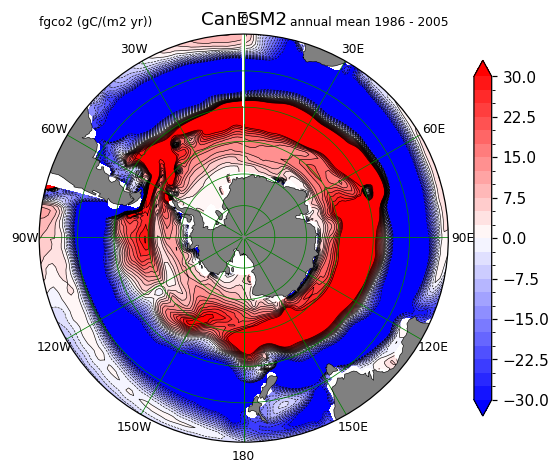

In [7]:
levels = np.arange(-30, 30.1, 2.5)
cmap = plt.get_cmap("bwr")
norm = BoundaryNorm(levels, cmap.N, extend="both")

# Circular polar boundary
theta = np.linspace(0, 2 * np.pi, 100)
circle = mpath.Path(
    np.c_[np.sin(theta), np.cos(theta)] * 0.5 + 0.5
)

cubes = fgco2_cubes
fig = plt.figure(figsize=(6 * len(cubes), 6))

for i, (name, cube) in enumerate(cubes.items()):
    data = np.ma.masked_invalid(cube.data) * -31540000000.0
    lat = coord_1d_or_2d(cube, "latitude")
    lon = coord_1d_or_2d(cube, "longitude")
    if lat.ndim == 1:
        lon, lat = np.meshgrid(lon, lat)

    ax = fig.add_subplot(
        1, len(cubes), i + 1, projection=ccrs.SouthPolarStereo()
    )
    ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)

    cf = ax.contourf(
        lon, lat, data, levels=levels, cmap=cmap, norm=norm,
        extend="both", transform=ccrs.PlateCarree()
    )
    ax.contour(
        lon, lat, data, levels=levels, colors="black",
        linewidths=0.4, transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.LAND, facecolor="grey", zorder=2)
    ax.coastlines(linewidth=0.4, zorder=3)
    ax.gridlines(
        xlocs=np.arange(-180, 181, 30),
        ylocs=np.arange(-90, -29, 10),
        color="green", linewidth=0.5
    )

    # Longitude labels around the circle
    for x in np.arange(-150, 181, 30):
        a = np.deg2rad(x)
        label = (
            "0" if x == 0 else
            "180" if abs(x) == 180 else
            f"{abs(x)}{'E' if x > 0 else 'W'}"
        )
        ax.text(
            0.5 + 0.535 * np.sin(a),
            0.5 + 0.535 * np.cos(a),
            label, transform=ax.transAxes,
            ha="center", va="center", fontsize=8,
            clip_on=False
        )

    ax.set_title(name)
    ax.text(0, 1.02, "fgco2 (gC/(m2 yr))",
            transform=ax.transAxes, fontsize=8)
    ax.text(1, 1.02, "annual mean 1986 - 2005",
            transform=ax.transAxes, ha="right", fontsize=8)

    fig.colorbar(cf, ax=ax, shrink=0.7)

plt.show()

**Figure 7: Annual mean CO2 flux:** Annual mean sea-to-air CO2 flux (gC/(m^2 yr)); positive (red) is a flux
out of the ocean.